In [22]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

import PIL
import gc
import glob
import shutil
import seaborn as sns  # Fixed import name
from PIL import ImageStat, Image
from collections import Counter
import tifffile  # Use tifffile instead of openslide for regular TIFF files
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio
from skimage import measure, color, exposure, filters, morphology
import cv2

Image shape: (2464, 2056, 3)


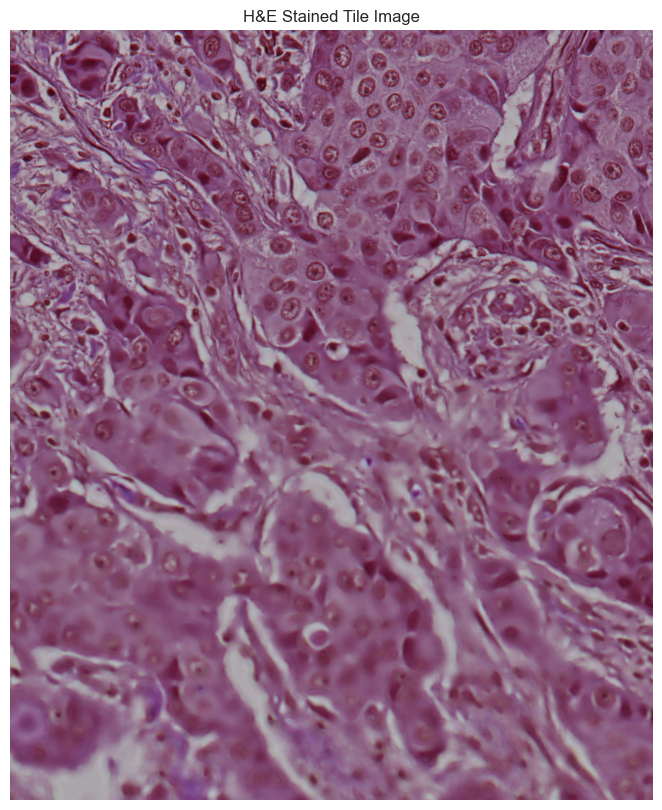

In [10]:
wsi_path = "picture/HE_20X_ED7_tile_01821.tiff"
tile_image = tifffile.imread(wsi_path)
print(f"Image shape: {tile_image.shape}")

# 顯示圖像
plt.figure(figsize=(10, 10))
plt.imshow(tile_image)
plt.axis('off')  # 隱藏座標軸
plt.title('H&E Stained Tile Image')
plt.show()


rgb_analyze

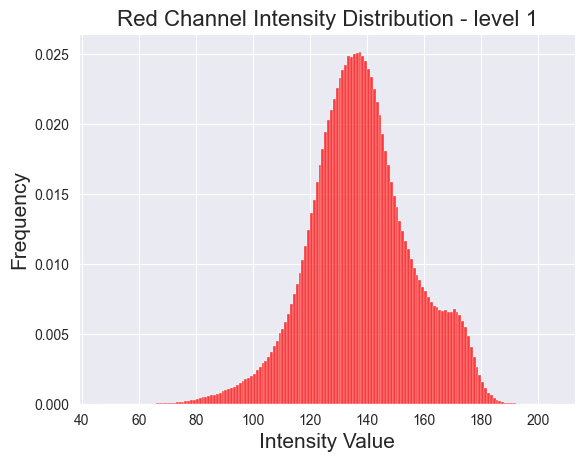

In [3]:
# Extract red channel data
if len(tile_image.shape) == 3 and tile_image.shape[2] >= 3:
    red_channel_data = tile_image[:, :, 0].flatten()
elif len(tile_image.shape) == 2:
    # Grayscale image
    red_channel_data = tile_image.flatten()
else:
    raise ValueError(f"Unexpected image shape: {tile_image.shape}")

# Add a variable for level since it's used later but not defined
level = 0

sns.histplot(red_channel_data, color="red", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'Red Channel Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'red_channel_intdist_level_{level+1}.png')
plt.show()

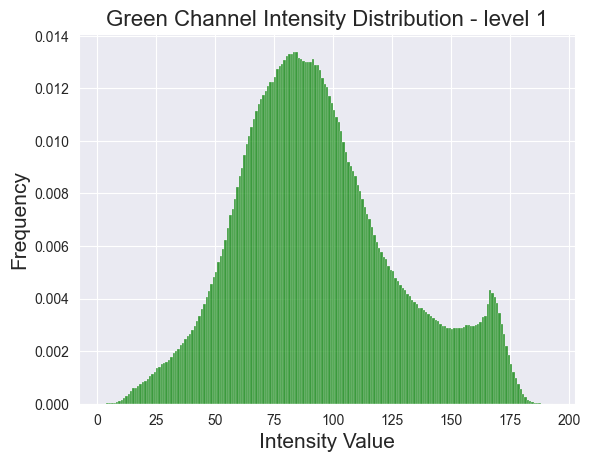

In [4]:
# Extract green channel data
if len(tile_image.shape) == 3 and tile_image.shape[2] >= 3:
    green_channel_data = tile_image[:, :, 1].flatten()
elif len(tile_image.shape) == 2:
    # Grayscale image
    green_channel_data = tile_image.flatten()
else:
    raise ValueError(f"Unexpected image shape: {tile_image.shape}")

# Add a variable for level since it's used later but not defined
level = 0

sns.histplot(green_channel_data, color="green", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'Green Channel Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'green_channel_intdist_level_{level+1}.png')
plt.show()

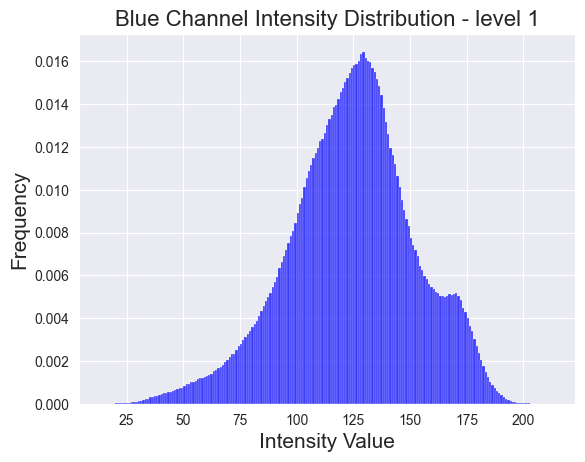

In [5]:
# Extract red channel data
if len(tile_image.shape) == 3 and tile_image.shape[2] >= 3:
    blue_channel_data = tile_image[:, :, 2].flatten()
elif len(tile_image.shape) == 2:
    # Grayscale image
    blue_channel_data = tile_image.flatten()
else:
    raise ValueError(f"Unexpected image shape: {tile_image.shape}")

# Add a variable for level since it's used later but not defined
level = 0

sns.histplot(blue_channel_data, color="blue", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'Blue Channel Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'blue_channel_intdist_level_{level+1}.png')
plt.show()

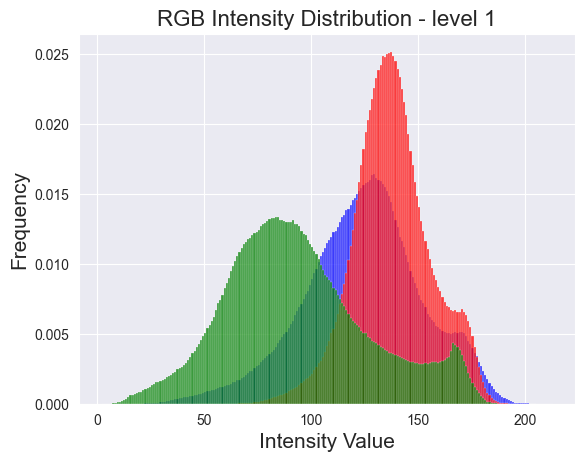

In [6]:
sns.histplot(blue_channel_data, color="blue", binwidth=1, stat="probability")
sns.histplot(red_channel_data, color="red", binwidth=1, stat="probability")
sns.histplot(green_channel_data, color="green", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'RGB Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'rgb_channel_intdist_level_{level+1}.png')
plt.show()

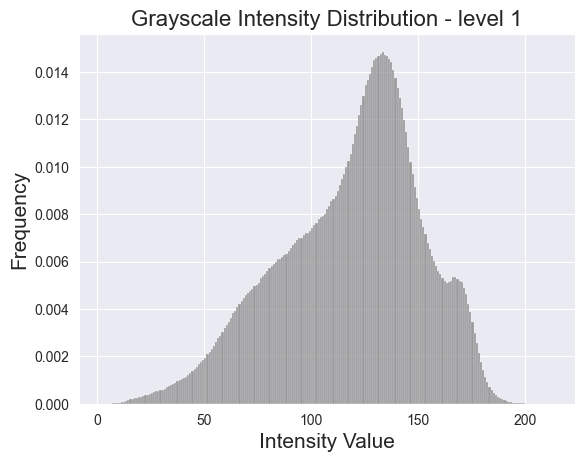

In [7]:
grayscale_data = np.array(tile_image).flatten()

sns.histplot(grayscale_data, color="gray", binwidth=1, stat="probability")
plt.xlabel('Intensity Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.title(f'Grayscale Intensity Distribution - level {level+1}', fontsize=16)
plt.savefig(f'grayscale_intdist_level_{level+1}.png')
plt.show()

In [105]:
# 2. RGB -> HED
hed = color.rgb2hed(tile_image)
H = hed[:, :, 0]  # Hematoxylin

# 3. 只對 H 通道做對比度拉伸
p2, p98 = np.percentile(H, (2, 98))
H_stretched = exposure.rescale_intensity(H, in_range=(p2, p98), out_range=(0, 1))

# 4. CLAHE 增強
H_clahe = exposure.equalize_adapthist(H_stretched, clip_limit=0.03)

# 5. Gamma 校正（可選）
H_gamma = exposure.adjust_gamma(H_clahe, gamma=0.7)

# 6. Otsu 分割得到核遮罩
th = filters.threshold_otsu(H_gamma)
mask = H_gamma > th
mask = morphology.remove_small_objects(mask, min_size=16)

# 7. 將遮罩套回原始 RGB（僅保留細胞核區域）
H_nuclei_rgb = np.zeros_like(tile_image, dtype=float)
for c in range(3):
    H_nuclei_rgb[..., c] = tile_image[..., c] * mask

In [106]:
# 設置中文字體支援
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


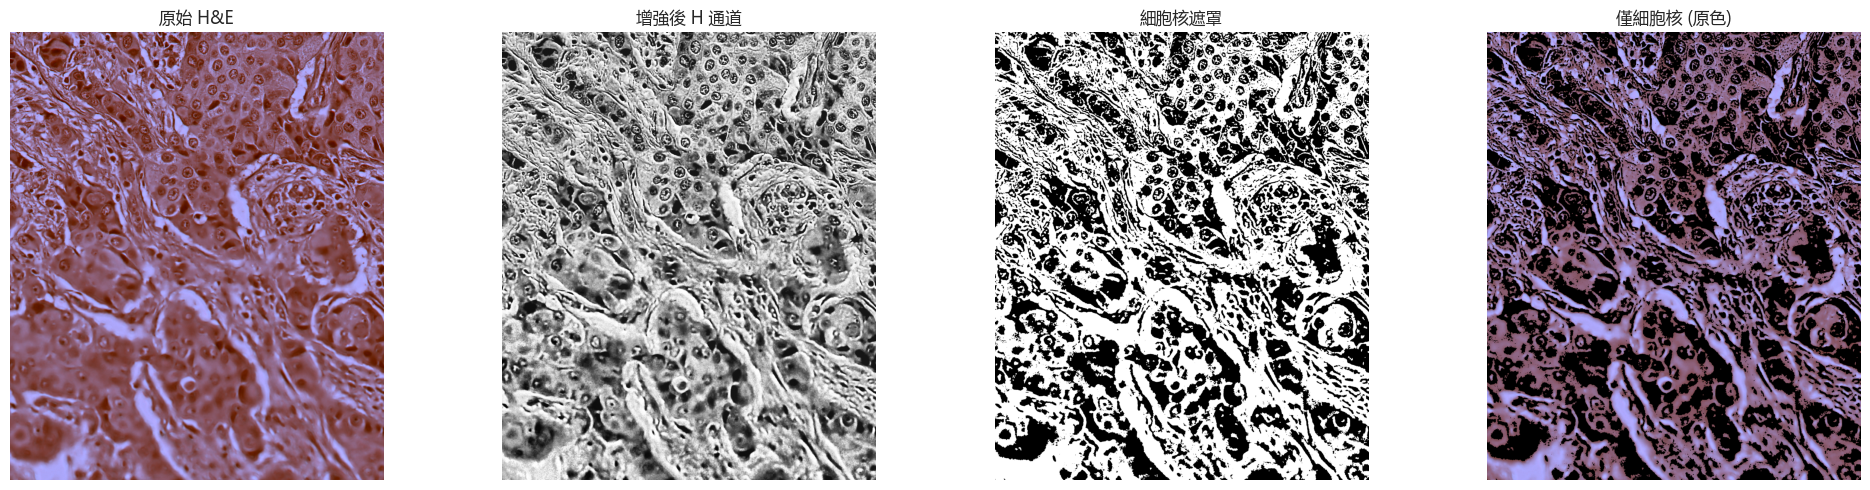

In [108]:
# 8. 顯示結果
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(tile_image)
axes[0].set_title("原始 H&E")
axes[0].axis('off')

axes[1].imshow(H_gamma, cmap='gray')
axes[1].set_title("增強後 H 通道")
axes[1].axis('off')

axes[2].imshow(mask, cmap='gray')
axes[2].set_title("細胞核遮罩")
axes[2].axis('off')

axes[3].imshow(H_nuclei_rgb.astype(np.uint8))
axes[3].set_title("僅細胞核 (原色)")
axes[3].axis('off')

plt.tight_layout()
plt.show()